# Level 1 · Task 2 — Simple Linear Regression
### Codveda Technologies — Machine Learning Internship
**Intern:** Mouhamed Diop · **ID:** CV/A1/79278

---
**Goal:** Build a linear regression model to predict a continuous variable — **house prices (MEDV)**.

**Steps:** load & explore → split & scale → train → interpret coefficients → evaluate (R², MSE) → visualize.
**Dataset:** Boston-style housing (`house_prediction.csv`). **Tools:** Python, pandas, scikit-learn.

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
print("Libraries loaded.")

Libraries loaded.


## Step 1 — Load the Data
The file is whitespace-separated with no header, so we assign the 14 standard column names.
`MEDV` (median home value, in $1000s) is the target.

In [2]:
columns = ["CRIM","ZN","INDUS","CHAS","NOX","RM","AGE",
           "DIS","RAD","TAX","PTRATIO","B","LSTAT","MEDV"]
df = pd.read_csv("../../data/house_prediction.csv", sep=r"\s+", header=None, names=columns)
print("Shape:", df.shape)
df.head()

Shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## Step 2 — Explore
Check missing values and the correlation of each feature with the target.

In [3]:
print("Missing values:", df.isnull().sum().sum())
df.describe().T

Missing values: 0


,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


In [4]:
corr = df.corr()["MEDV"].sort_values(ascending=False)
print(corr)

MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64


**Insight:** `RM` (rooms, +0.70) is the strongest positive driver of price, while
`LSTAT` (% lower-status population, −0.74) is the strongest negative driver.

## Step 3 — Split & Scale
Separate features (X) from target (y), split 80/20, and standardize features
(fit on train only to avoid data leakage).

In [5]:
X = df.drop(columns=["MEDV"])
y = df["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (404, 13)  Test: (102, 13)


## Step 4 — Train the Linear Regression Model

In [6]:
model = LinearRegression()
model.fit(X_train_s, y_train)
print("Model trained.")
print("Intercept (baseline price):", round(model.intercept_, 3))

Model trained.
Intercept (baseline price): 22.797


## Step 5 — Interpret the Coefficients
Because features are standardized, each coefficient shows the price change (in $1000s)
for a **one-standard-deviation** increase in that feature — so magnitudes are comparable.

LSTAT     -3.611658
RM         3.145240
DIS       -3.081908
RAD        2.251407
PTRATIO   -2.037752
NOX       -2.022319
TAX       -1.767014
B          1.129568
CRIM      -1.002135
CHAS       0.718738
ZN         0.696269
INDUS      0.278065
AGE       -0.176048
dtype: float64


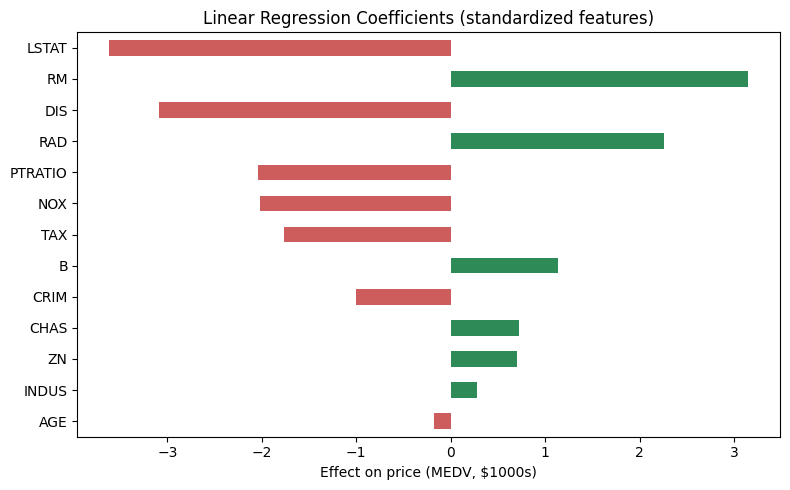

In [7]:
coefs = pd.Series(model.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print(coefs)

plt.figure(figsize=(8,5))
coefs.iloc[::-1].plot.barh(color=np.where(coefs.iloc[::-1]>0,"seagreen","indianred"))
plt.title("Linear Regression Coefficients (standardized features)")
plt.xlabel("Effect on price (MEDV, $1000s)")
plt.tight_layout()
plt.savefig("output_coefficients.png", dpi=110)
plt.show()

**Reading it:** positive bars push the price up (e.g. `RM`), negative bars pull it down
(e.g. `LSTAT`, `DIS`, `PTRATIO`).

## Step 6 — Evaluate the Model
- **R²**: share of price variance explained (1 = perfect, 0 = no better than the mean).
- **MSE / RMSE**: average squared / root-squared prediction error (lower = better).

In [8]:
y_pred = model.predict(X_test_s)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"R-squared : {r2:.3f}")
print(f"MSE       : {mse:.3f}")
print(f"RMSE      : {rmse:.3f}  (avg error in $1000s)")

R-squared : 0.669
MSE       : 24.291
RMSE      : 4.929  (avg error in $1000s)


## Step 7 — Visualize: Predicted vs Actual & Residuals

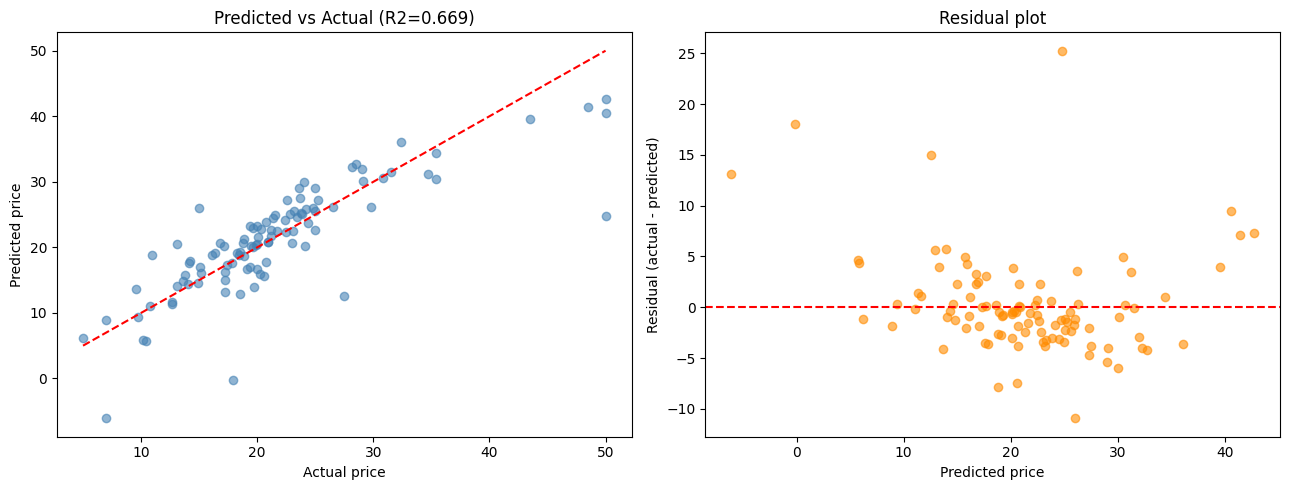

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13,5))

# Predicted vs actual
ax[0].scatter(y_test, y_pred, alpha=0.6, color="steelblue")
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
ax[0].set_xlabel("Actual price"); ax[0].set_ylabel("Predicted price")
ax[0].set_title(f"Predicted vs Actual (R2={r2:.3f})")

# Residuals
residuals = y_test - y_pred
ax[1].scatter(y_pred, residuals, alpha=0.6, color="darkorange")
ax[1].axhline(0, color="red", linestyle="--")
ax[1].set_xlabel("Predicted price"); ax[1].set_ylabel("Residual (actual - predicted)")
ax[1].set_title("Residual plot")

plt.tight_layout()
plt.savefig("output_predictions.png", dpi=110)
plt.show()

**Reading it:** points near the red dashed line = accurate predictions. Residuals scattered
randomly around 0 (no clear pattern) means the linear model fits reasonably well.

## Summary
| Metric | Value |
|--------|-------|
| R² (test) | ~0.67 |
| RMSE | ~4.9 ($1000s) |

The model explains about **67%** of the variation in house prices. The most influential
features are `LSTAT` and `RM`. ✅ **Level 1 · Task 2 complete.**